In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.layers import Bidirectional, Embedding, Dense, SpatialDropout1D, Dropout, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import xgboost as xgb
from tensorflow.keras.layers import Bidirectional, Embedding, Dense, SpatialDropout1D, Dropout, LSTM

!pip install emoji
import emoji


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.8 MB/s eta 0:00:00


#**LOAD DATASET**

In [3]:
import pandas as pd

reviews_df = pd.read_csv('scrap_shopee.csv')
reviews_df.shape

(10000, 11)

In [4]:
reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c0cefd70-1246-4e6d-b537-fa1f94931ef5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"1. Fitur ""Pengurutan Etalase Produk"" tidak aku...",4,64,3.67.27,2026-02-15 04:03:02,"Hi Kak Ricki, makasih ya buat bintang 4 nya. T...",2025-12-21 15:13:03,3.67.27
1,f4f2abe0-6acc-4737-8bcf-d48020f97f51,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kenapa akhir² ini shopee tdk menerapkan gratis...,3,77,3.68.35,2026-02-13 01:40:32,NaN,NaN,3.68.35
2,e05ec8c1-090e-439d-8d65-f02cbb819186,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,pengiriman shopee akhir² ini mengalami penurun...,1,89,3.67.27,2026-02-11 17:00:53,Hi kak Eka Putri Lestari maaf ya terkait kenda...,2026-02-11 18:12:24,3.67.27
3,28f70d6a-e963-4fce-b1a7-e6e7371e5214,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"memang belanja di shope sangat memuaskan,, tap...",1,55,3.67.27,2026-02-12 13:00:58,"Hi kak Shaputra, maaf ya sudah buat kmu gak ny...",2026-02-12 14:24:45,3.67.27
4,ea4d5dc2-0bf8-4e58-9907-c2cfde567a89,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jasa ekspedisi rekomendasi dari Shopee jelek b...,1,45,3.67.27,2026-02-12 00:36:00,"Hi kak Aprianti Renata, maaf bikin ga nyaman t...",2026-02-12 02:13:26,3.67.27


In [5]:
reviews_df.columns.tolist()

['reviewId',
 'userName',
 'userImage',
 'content',
 'score',
 'thumbsUpCount',
 'reviewCreatedVersion',
 'at',
 'replyContent',
 'repliedAt',
 'appVersion']

In [6]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              10000 non-null  object
 1   userName              10000 non-null  object
 2   userImage             10000 non-null  object
 3   content               10000 non-null  object
 4   score                 10000 non-null  int64 
 5   thumbsUpCount         10000 non-null  int64 
 6   reviewCreatedVersion  10000 non-null  object
 7   at                    10000 non-null  object
 8   replyContent          9327 non-null   object
 9   repliedAt             9327 non-null   object
 10  appVersion            10000 non-null  object
dtypes: int64(2), object(9)
memory usage: 859.5+ KB


#**PRE-PROCESSING**

In [7]:
clean_df = reviews_df.dropna()
clean_df = clean_df.drop_duplicates()
clean_df.shape

(9327, 11)

In [8]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = emoji.replace_emoji(text, replace='') # menghapus emoji pakai library emoji
    text = re.sub(r'[' + string.punctuation + ']', ' ', text) # Hapus tanda baca tapi pertahankan spasi
    text = re.sub(r'\s+', ' ', text).strip()  # Hapus multiple spasi
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence


In [9]:
# Mengubah slang word jadi formal

slang_df = pd.read_csv("new_kamusalay.csv", encoding='latin‑1', names=['original','replacement'], header=None)
slang_map = dict(zip(slang_df['original'].str.lower(), slang_df['replacement'].str.lower()))

def fix_slangwords(text):
    words = text.split()
    fixed = [slang_map.get(w.lower(), w) for w in words]
    return ' '.join(fixed)

In [10]:
# Cleaning kolom 'content' dan menyimpannya di 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_tosentence'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [11]:
clean_df['text_akhir']

,text_akhir
0,fitur pengurutan etalase produk akurat ulasan ...
2,pengiriman shopee akhir² mengalami penurunan b...
3,belanja shope memuaskan puas kurir² nya barang...
4,jasa ekspedisi rekomendasi shopee jelek banget...
5,tolong shopee pengiriman barang sesuai tanggal...
...,...
9995,berlangganan banget shoppe member platinum pok...
9996,puas belanja proses komplain retur refund cepa...
9997,shopee membantu mencari barang dibutuhkan teri...
9998,buka langsung muncul video mengganggu pindah b...


#**LABELING**

In [12]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [13]:
def sentiment_score(text, pos_lex, neg_lex):
    words = text.split()
    score = 0
    for w in words:
        if w in pos_lex:
            score += pos_lex[w]
        elif w in neg_lex:
            score += neg_lex[w]
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

clean_df['polarity'] = clean_df['text_akhir'].apply(lambda x: sentiment_score(x, lexicon_positive, lexicon_negative))


In [14]:
print(clean_df['polarity'].value_counts())

polarity
positive    7040
negative    1990
neutral      297
Name: count, dtype: int64


In [15]:
clean_df[['text_akhir', 'polarity']].head(100)

,text_akhir,polarity
0,fitur pengurutan etalase produk akurat ulasan ...,positive
2,pengiriman shopee akhir² mengalami penurunan b...,negative
3,belanja shope memuaskan puas kurir² nya barang...,positive
4,jasa ekspedisi rekomendasi shopee jelek banget...,positive
5,tolong shopee pengiriman barang sesuai tanggal...,negative
...,...,...
102,pelayanan profesional konsumen kecewa menangan...,positive
103,ekspedisi pilihan berakibat terlambat estimasi...,positive
104,ongkos kirim ngotak nama sub total ukuran khus...,positive
105,mengajukan keluhan telfon email penanganan cep...,positive


## Distribusi Label

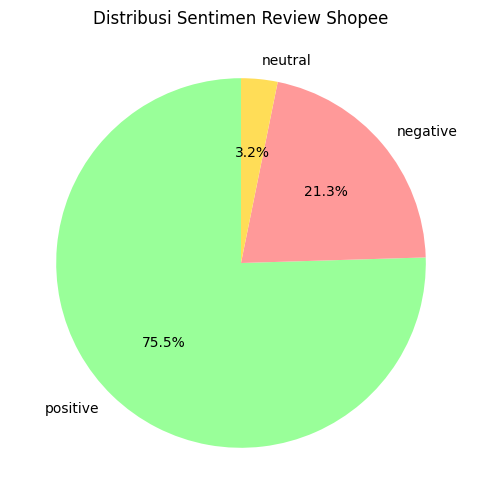

In [16]:
# hitung distribusi label
label_counts = clean_df['polarity'].value_counts()

# mapping warna
color_map = {
    'positive': '#99ff99',
    'neutral':  '#ffdd57',
    'negative': '#ff9999'
}
colors = [color_map[label] for label in label_counts.index]

plt.figure(figsize=(6,6))
plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title("Distribusi Sentimen Review Shopee")
plt.show()


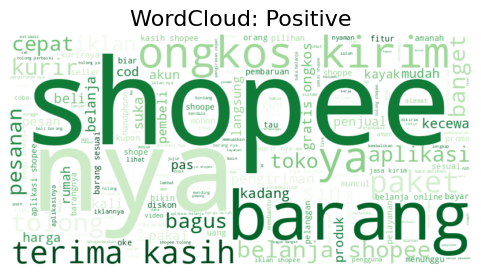

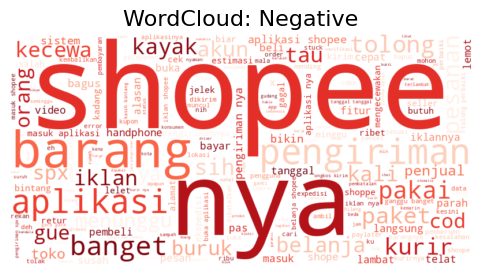

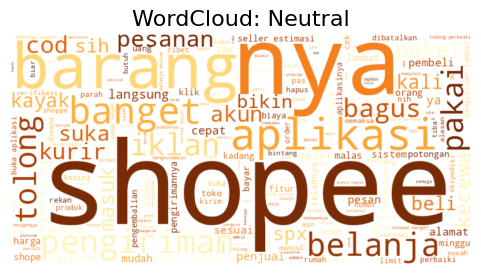

In [17]:
def generate_wordcloud(text_series, title, cmap):
    text = ' '.join(text_series)
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=cmap
    ).generate(text)

    plt.figure(figsize=(6,3))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

cmap_map = {
    'positive': 'Greens',
    'neutral': 'YlOrBr',
    'negative': 'Reds'
}

for label in clean_df['polarity'].unique():
    generate_wordcloud(
        clean_df.loc[clean_df['polarity'] == label, 'text_akhir'],
        f"WordCloud: {label.capitalize()}",
        cmap_map[label]
    )


## Hasil WordCloud Setelah Penerapan TF-IDF

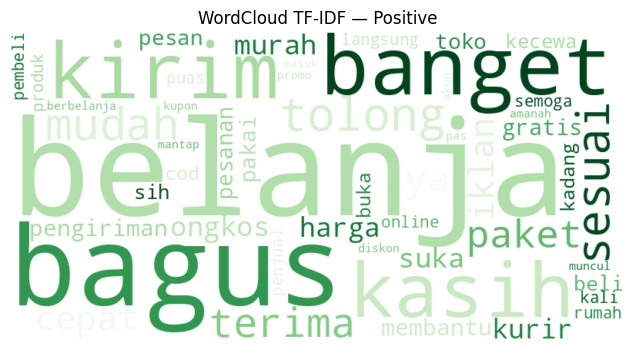

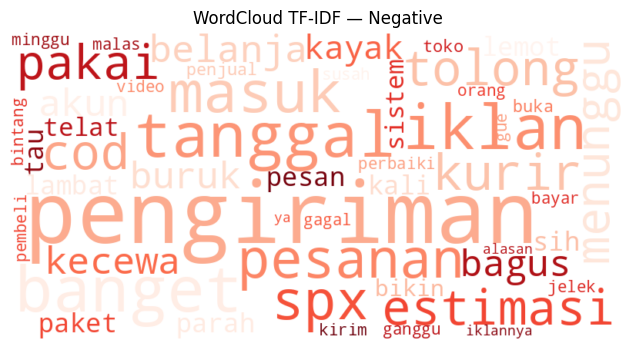

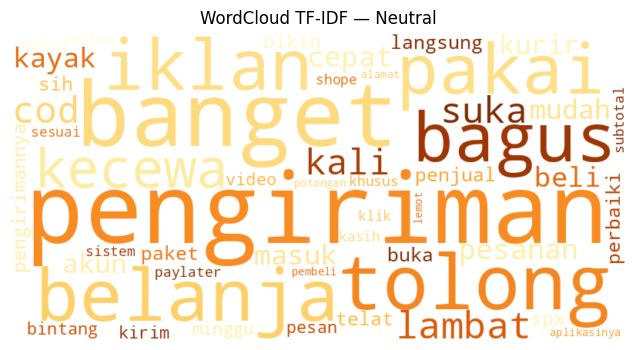

In [18]:
custom_stopwords = ['shopee', 'nya', 'barang', 'aplikasi']

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words=custom_stopwords
)

X = vectorizer.fit_transform(clean_df['text_akhir'])
feature_names = np.array(vectorizer.get_feature_names_out())

cmap_map = {
    'positive': 'Greens',
    'neutral': 'YlOrBr',
    'negative': 'Reds'
}

def tfidf_wordcloud(label, top_n=50):
    idx = clean_df['polarity'] == label
    tfidf_mean = X[idx.values].mean(axis=0).A1

    top_idx = tfidf_mean.argsort()[-top_n:]
    word_weights = dict(zip(feature_names[top_idx], tfidf_mean[top_idx]))

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=cmap_map[label]
    ).generate_from_frequencies(word_weights)

    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud TF-IDF — {label.capitalize()}")
    plt.show()

for label in clean_df['polarity'].unique():
    tfidf_wordcloud(label)


#**PREDIKSI**

In [19]:
df = clean_df[['text_akhir', 'polarity']]

# pisahkan per kelas
df_positive = df[df.polarity == 'positive']
df_neutral  = df[df.polarity == 'neutral']
df_negative = df[df.polarity == 'negative']

# Oversampling
df_neutral_up  = resample(df_neutral, replace=True, n_samples=len(df_neutral)*3, random_state=42)
df_negative_up = resample(df_negative, replace=True, n_samples=len(df_negative)*2, random_state=42)

# Gabungkan semua
df_balanced = pd.concat([df_positive, df_neutral_up, df_negative_up])

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Features & Labels
X = df_balanced['text_akhir'].values
y = df_balanced['polarity'].values

print("Jumlah per kelas setelah oversampling:")
print(df_balanced.polarity.value_counts())


Jumlah per kelas setelah oversampling:
polarity
positive    7040
negative    3980
neutral      891
Name: count, dtype: int64


##Kombinasi 1
Model: TF-IDF + XGBoost (70/30)

In [20]:
print("\n" + "="*60)
print("KOMBINASI 1: XGBoost + TF-IDF (70/30)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

label_map = {'negative':0, 'neutral':1, 'positive':2}
y_train_enc = np.array([label_map[l] for l in y_train])
y_test_enc  = np.array([label_map[l] for l in y_test])

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_tfidf, y_train_enc)

y_train_pred = xgb_model.predict(X_train_tfidf)
y_test_pred  = xgb_model.predict(X_test_tfidf)

train_acc = accuracy_score(y_train_enc, y_train_pred)
test_acc  = accuracy_score(y_test_enc, y_test_pred)

print(f"Kombinasi 1 → Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

inv_label_map = {0:'negative', 1:'neutral', 2:'positive'}
y_test_pred_label = [inv_label_map[i] for i in y_test_pred]

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_label))



KOMBINASI 1: XGBoost + TF-IDF (70/30)
Kombinasi 1 → Train Accuracy: 0.9562 | Test Accuracy: 0.8830

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86      1194
     neutral       0.99      0.58      0.73       267
    positive       0.89      0.94      0.91      2113

    accuracy                           0.88      3574
   macro avg       0.91      0.79      0.83      3574
weighted avg       0.89      0.88      0.88      3574



In [30]:
import joblib

joblib.dump({
    'model': xgb_model,
    'tfidf': tfidf,
    'label_map': {
        0: 'negative',
        1: 'neutral',
        2: 'positive'
    }
}, 'sentiment_model_XGBoost_TFIDF_70_30.joblib')

print("Model XGBoost + TF-IDF berhasil disimpan ke 'sentiment_model_XGBoost_TFIDF_70_30.joblib'")


Model XGBoost + TF-IDF berhasil disimpan ke 'sentiment_model_XGBoost_TFIDF_70_30.joblib'


##Kombinasi 2
LSTM + Word2Vec (80/20)

In [21]:
print("\n" + "="*60)
print("KOMBINASI 2: Word2Vec + LSTM (80/20)")
print("="*60)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tokens = [text.split() for text in X_train3]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train3)

X_train_seq = tokenizer.texts_to_sequences(X_train3)
X_test_seq  = tokenizer.texts_to_sequences(X_test3)

maxlen = 50
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad  = pad_sequences(X_test_seq, maxlen=maxlen)

vocab_size = len(tokenizer.word_index) + 1

label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

y_train_enc = np.array([label_map[l] for l in y_train3])
y_test_enc  = np.array([label_map[l] for l in y_test3])


lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=maxlen),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

train_loss, train_acc = lstm_model.evaluate(X_train_pad, y_train_enc, verbose=0)
test_loss, test_acc   = lstm_model.evaluate(X_test_pad, y_test_enc, verbose=0)

print(f"Kombinasi 2 → Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

y_test_pred_prob = lstm_model.predict(X_test_pad)
y_test_pred_enc  = np.argmax(y_test_pred_prob, axis=1)

inv_label_map = {0:'negative', 1:'neutral', 2:'positive'}
y_test_pred_label = [inv_label_map[i] for i in y_test_pred_enc]

print("\nClassification Report:")
print(classification_report(y_test3, y_test_pred_label))



KOMBINASI 2: Word2Vec + LSTM (80/20)
Epoch 1/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.6075 - loss: 0.8747 - val_accuracy: 0.8489 - val_loss: 0.4321
Epoch 2/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.8768 - loss: 0.3168 - val_accuracy: 0.9129 - val_loss: 0.2773
Epoch 3/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 25s 130ms/step - accuracy: 0.9562 - loss: 0.1451 - val_accuracy: 0.9307 - val_loss: 0.2587
Epoch 4/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.9759 - loss: 0.0777 - val_accuracy: 0.9339 - val_loss: 0.2621
Epoch 5/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.9871 - loss: 0.0525 - val_accuracy: 0.9360 - val_loss: 0.2559
Kombinasi 2 → Train Accuracy: 0.9907 | Test Accuracy: 0.9371
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.93      0.92      0.93       796
     neutral       0.80      0.92      0.85       178
    positive       0.96    

In [32]:
lstm_model.save("sentiment_model_LSTM_W2V_80_20.h5")
print("Model LSTM berhasil disimpan")

Model LSTM berhasil disimpan


In [31]:
import joblib

joblib.dump({
    'tokenizer': tokenizer,
    'word2vec': w2v_model,
    'label_map': {
        0: 'negative',
        1: 'neutral',
        2: 'positive'
    },
    'max_len': maxlen
}, 'sentiment_model_LSTM_W2V_80_20_config.joblib')

print("berhasil disimpan")


berhasil disimpan


##Kombinasi 3
GRU +  Word2Vec (80/20)

In [22]:
print("\n" + "="*60)
print("KOMBINASI 3: Word2Vec + GRU (80/20)")
print("="*60)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tokens = [text.split() for text in X_train3]

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train3)

X_train_seq = tokenizer.texts_to_sequences(X_train3)
X_test_seq  = tokenizer.texts_to_sequences(X_test3)

maxlen = 50
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad  = pad_sequences(X_test_seq, maxlen=maxlen)

vocab_size = len(tokenizer.word_index) + 1

label_map = {'negative':0, 'neutral':1, 'positive':2}
y_train_enc = np.array([label_map[l] for l in y_train3])
y_test_enc  = np.array([label_map[l] for l in y_test3])

gru_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=maxlen),
    GRU(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

train_loss, train_acc = gru_model.evaluate(X_train_pad, y_train_enc, verbose=0)
test_loss, test_acc   = gru_model.evaluate(X_test_pad, y_test_enc, verbose=0)

print(f"Kombinasi 3 → Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

y_test_pred_prob = gru_model.predict(X_test_pad)
y_test_pred_enc  = np.argmax(y_test_pred_prob, axis=1)

inv_label_map = {0:'negative', 1:'neutral', 2:'positive'}
y_test_pred_label = [inv_label_map[i] for i in y_test_pred_enc]

print("\nClassification Report:")
print(classification_report(y_test3, y_test_pred_label))



KOMBINASI 3: Word2Vec + GRU (80/20)
Epoch 1/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.6079 - loss: 0.8730 - val_accuracy: 0.8594 - val_loss: 0.3852
Epoch 2/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.8783 - loss: 0.3251 - val_accuracy: 0.8877 - val_loss: 0.3189
Epoch 3/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.9543 - loss: 0.1451 - val_accuracy: 0.9098 - val_loss: 0.2740
Epoch 4/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9747 - loss: 0.0876 - val_accuracy: 0.9203 - val_loss: 0.2868
Epoch 5/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.9798 - loss: 0.0636 - val_accuracy: 0.9140 - val_loss: 0.3436
Kombinasi 3 → Train Accuracy: 0.9825 | Test Accuracy: 0.9178
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.93      0.91       796
     neutral       0.72      0.88      0.79       178
    positive       0.96      0

In [33]:
gru_model.save("sentiment_model_GRU_W2V_80_20.h5")
print("Model GRU berhasil disimpan")


Model GRU berhasil disimpan


In [34]:
import joblib

joblib.dump({
    'tokenizer': tokenizer,
    'word2vec': w2v_model,
    'label_map': {
        0: 'negative',
        1: 'neutral',
        2: 'positive'
    },
    'max_len': maxlen
}, 'sentiment_model_GRU_W2V_80_20_config.joblib')

print("Tokenizer, Word2Vec, dan config berhasil disimpan")


Tokenizer, Word2Vec, dan config berhasil disimpan


## Kombinasi 4

BiLSTM + Embedding (80/20)

In [26]:
print("\n" + "="*60)
print("Kombinasi 4 : BiLSTM")
print("="*60)

# Re-initialize and fit tokenizer on all data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)

# Convert text to sequences and pad
X_seq = tokenizer.texts_to_sequences(X)
maxlen = 50 # Reusing from previous combinations
X_pad = pad_sequences(X_seq, maxlen=maxlen)

# Encode labels
label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}
labels_enc = np.array([label_map[l] for l in y])

# SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, labels_enc, test_size=0.2, random_state=42, stratify=labels_enc
)

# Define model parameters
max_words = len(tokenizer.word_index) + 1
max_len = maxlen # Alias for clarity
epochs = 5 # Example value
batch_size = 64 # Example value

# Compute class weights for imbalanced dataset
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i : class_weights[i] for i in range(len(class_weights))}

# MODEL
model = Sequential([
    Embedding(max_words, 128, input_length=max_len, mask_zero=True),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    Bidirectional(LSTM(32, dropout=0.2)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CALLBACK
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# TRAINING
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# EVALUASI
train_acc = model.evaluate(X_train, y_train, verbose=0)[1]
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"\nSKEMA 4 ({epochs} EPOCH) → Train: {train_acc:.4f}, Test: {test_acc:.4f}")


Kombinasi 4 : BiLSTM
Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 61s 305ms/step - accuracy: 0.5849 - loss: 0.9867 - val_accuracy: 0.8401 - val_loss: 0.4301 - learning_rate: 0.0010
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 81s 300ms/step - accuracy: 0.8888 - loss: 0.3930 - val_accuracy: 0.8846 - val_loss: 0.3403 - learning_rate: 0.0010
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.9569 - loss: 0.1692 - val_accuracy: 0.9257 - val_loss: 0.2286 - learning_rate: 0.0010
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 44s 293ms/step - accuracy: 0.9755 - loss: 0.0946 - val_accuracy: 0.9282 - val_loss: 0.2465 - learning_rate: 0.0010
Epoch 5/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9857 - loss: 0.0642
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 311ms/step - accuracy: 0.9857 - loss: 0.0642 - val_accuracy: 0.9257 - val_loss: 0.2866 - learning_rate: 0.0010

SKEMA 4 (5 EPOCH) → Train: 0.9928, Test: 0.9257


In [28]:
# Prediksi
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

le = LabelEncoder()
le.fit(df_balanced['polarity'])

# Mapping label kembali ke teks
label_names = le.classes_
print("Label Mapping:", dict(enumerate(label_names)))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=label_names))

75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step
Label Mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.93      0.92       796
     neutral       0.74      0.92      0.82       178
    positive       0.97      0.92      0.94      1409

    accuracy                           0.93      2383
   macro avg       0.87      0.93      0.90      2383
weighted avg       0.93      0.93      0.93      2383



In [35]:
model.save("sentiment_model_BiLSTM_80_20.h5")
print("Model BiLSTM berhasil disimpan")


Model BiLSTM berhasil disimpan


In [36]:
import joblib

joblib.dump({
    'tokenizer': tokenizer,
    'label_map': {
        0: 'negative',
        1: 'neutral',
        2: 'positive'
    },
    'max_len': max_len,
    'max_words': max_words
}, 'sentiment_model_BiLSTM_80_20_config.joblib')

print("Tokenizer dan config BiLSTM berhasil disimpan")


Tokenizer dan config BiLSTM berhasil disimpan


## Kesimpulan
| Kombinasi | Model & Fitur     | Split | Train Acc | Test Acc | Macro F1 | Weighted F1 |
|----------|------------------|-------|-----------|----------|----------|-------------|
| 1 | XGBoost + TF-IDF  | 70/30 | 0.9562 | 0.8830 | 0.83 | 0.88 |
| 2 | Word2Vec + LSTM   | 80/20 | 0.9907 | 0.9371 | 0.91 | 0.94 |
| 3 | Word2Vec + GRU    | 80/20 | 0.9825 | 0.9178 | 0.88 | 0.92 |
| 4 | Word2Vec + BiLSTM | 80/20 | 0.9928 | 0.9257 | 0.90 | 0.93 |


Word2Vec + LSTM memiliki test accuracy, macro F1, dan weighted F1 tertinggi, sehingga merupakan model terbaik untuk eksperimen ini.